In [28]:
import pandas as pd

In [29]:
file_path = '/content/drive/MyDrive/프로젝트/EDA용 파일.xlsx'
df = pd.read_excel(file_path)
display(df.head())

,기업명,기업코드,평가년도,ESG등급,환경,사회,지배구조,ESG 등급조정,환경 등급조정,사회 등급조정,지배구조 등급조정,시장구분,산업코드,종가,대비,등락률,시가총액,지속가능경영보고서_발행,기업지배구조보고서_발행,보고서_발행_유형
0,가온전선,500,2022,B,C,B+,B+,NaN,NaN,NaN,NaN,KOSPI,C28302,NaN,NaN,NaN,NaN,1,0,지속가능경영
1,가온전선,500,2023,B+,B+,A,B,NaN,NaN,NaN,NaN,KOSPI,C28302,NaN,NaN,NaN,NaN,1,0,지속가능경영
2,가온전선,500,2024,B,A,A,C,NaN,NaN,NaN,NaN,KOSPI,C28302,NaN,NaN,NaN,NaN,1,1,둘 다 발행
3,가온전선,500,2025,B+,A,A+,B,NaN,NaN,NaN,NaN,KOSPI,C28302,82400.0,-2600.0,-3.06,1.363150e+12,1,1,둘 다 발행
4,경동나비엔,9450,2022,C,C,B,D,NaN,NaN,NaN,지배구조 등급조정(2022.11),KOSPI,C28520,NaN,NaN,NaN,NaN,0,0,미발행


In [30]:
selected_columns = [
    '기업명', '기업코드', '평가년도', 'ESG등급', '환경', '사회', '지배구조',
    '시장구분', '산업코드', '시가총액', '지속가능경영보고서_발행',
    '기업지배구조보고서_발행', '보고서_발행_유형'
]

# 필요한 컬럼만 선택하여 새로운 DataFrame 생성
DF = df[selected_columns].copy()

display(DF.head())

,기업명,기업코드,평가년도,ESG등급,환경,사회,지배구조,시장구분,산업코드,시가총액,지속가능경영보고서_발행,기업지배구조보고서_발행,보고서_발행_유형
0,가온전선,500,2022,B,C,B+,B+,KOSPI,C28302,NaN,1,0,지속가능경영
1,가온전선,500,2023,B+,B+,A,B,KOSPI,C28302,NaN,1,0,지속가능경영
2,가온전선,500,2024,B,A,A,C,KOSPI,C28302,NaN,1,1,둘 다 발행
3,가온전선,500,2025,B+,A,A+,B,KOSPI,C28302,1.363150e+12,1,1,둘 다 발행
4,경동나비엔,9450,2022,C,C,B,D,KOSPI,C28520,NaN,0,0,미발행


In [31]:
unique_기업코드_count = DF['기업코드'].nunique()
print(f"'기업코드' 컬럼의 고유한 값 개수: {unique_기업코드_count}")

'기업코드' 컬럼의 고유한 값 개수: 92


In [32]:
unique_companies = DF.drop_duplicates(subset=['기업코드']).copy()

In [33]:
unique_starts_with_C261 = unique_companies['산업코드'].astype(str).str.startswith('C261')
unique_count_C261 = unique_starts_with_C261.sum()
unique_count_not_C261 = len(unique_companies) - unique_count_C261

print(f"고유 기업 중 '산업코드'가 'C261'로 시작하는 기업 수: {unique_count_C261}개")
print(f"고유 기업 중 '산업코드'가 'C261'로 시작하지 않는 기업 수: {unique_count_not_C261}개")

고유 기업 중 '산업코드'가 'C261'로 시작하는 기업 수: 16개
고유 기업 중 '산업코드'가 'C261'로 시작하지 않는 기업 수: 76개


In [34]:
semiconductor_file_path = '/content/drive/MyDrive/프로젝트/반도체 list.xlsx'
semiconductor_df = pd.read_excel(semiconductor_file_path)

print("새로운 데이터프레임 'semiconductor_df'의 상위 5개 행:")
display(semiconductor_df.head())

새로운 데이터프레임 'semiconductor_df'의 상위 5개 행:


,기업명,기업코드,평가년도,ESG등급,환경,사회,지배구조,ESG 등급조정,환경 등급조정,사회 등급조정,...,업종명,산업코드,종가,대비,등락률,시가총액,지속가능경영보고서_발행,기업지배구조보고서_발행,보고서_발행_유형,비고
0,광전자,17900,C261,2022,D,D,D,C,NaN,NaN,...,KOSPI,전기·전자,NaN,NaN,NaN,NaN,0,0,미발행,NaN
1,광전자,17900,C261,2023,D,C,D,D,NaN,NaN,...,KOSPI,전기·전자,NaN,NaN,NaN,NaN,0,0,미발행,NaN
2,광전자,17900,C261,2024,C,C,D,C,NaN,NaN,...,KOSPI,전기·전자,NaN,NaN,NaN,NaN,0,0,미발행,NaN
3,광전자,17900,C261,2025,D,C,D,D,NaN,NaN,...,KOSPI,전기·전자,1802.0,1.0,0.06,1.044150e+11,0,0,미발행,NaN
4,네패스,33640,C261,2022,C,C,B+,D,NaN,NaN,...,KOSDAQ,전기·전자,NaN,NaN,NaN,NaN,0,0,미발행,NaN


In [35]:
unique_semiconductor_기업코드 = semiconductor_df['기업코드'].unique()
print(f"'semiconductor_df'에서 고유한 '기업코드' 개수: {len(unique_semiconductor_기업코드)}개")
print("고유한 '기업코드' 목록:")
display(unique_semiconductor_기업코드)

'semiconductor_df'에서 고유한 '기업코드' 개수: 20개
고유한 '기업코드' 목록:


array([ 17900,  33640,  58470,   5930,  46890,  33170,  11930, 101490,
        36810,  11690, 109070,  67310, 166090, 195870,    990,  92220,
       108320, 218410,  36540,    660])

In [36]:
is_semiconductor_company = unique_companies['기업코드'].isin(unique_semiconductor_기업코드)

semiconductor_count = is_semiconductor_company.sum()
not_semiconductor_count = len(unique_companies) - semiconductor_count

print(f"총 고유 기업 수: {len(unique_companies)}개\n")
print(f"반도체 기업 수: {semiconductor_count}개")
print(f"반도체 외 기업 수: {not_semiconductor_count}개")

# 2x2 표 형태로 출력
data = {'분류': ['반도체 기업', '반도체 외 기업'], '개수': [semiconductor_count, not_semiconductor_count]}
result_df = pd.DataFrame(data)
display(result_df)


총 고유 기업 수: 92개

반도체 기업 수: 20개
반도체 외 기업 수: 72개


,분류,개수
0,반도체 기업,20
1,반도체 외 기업,72


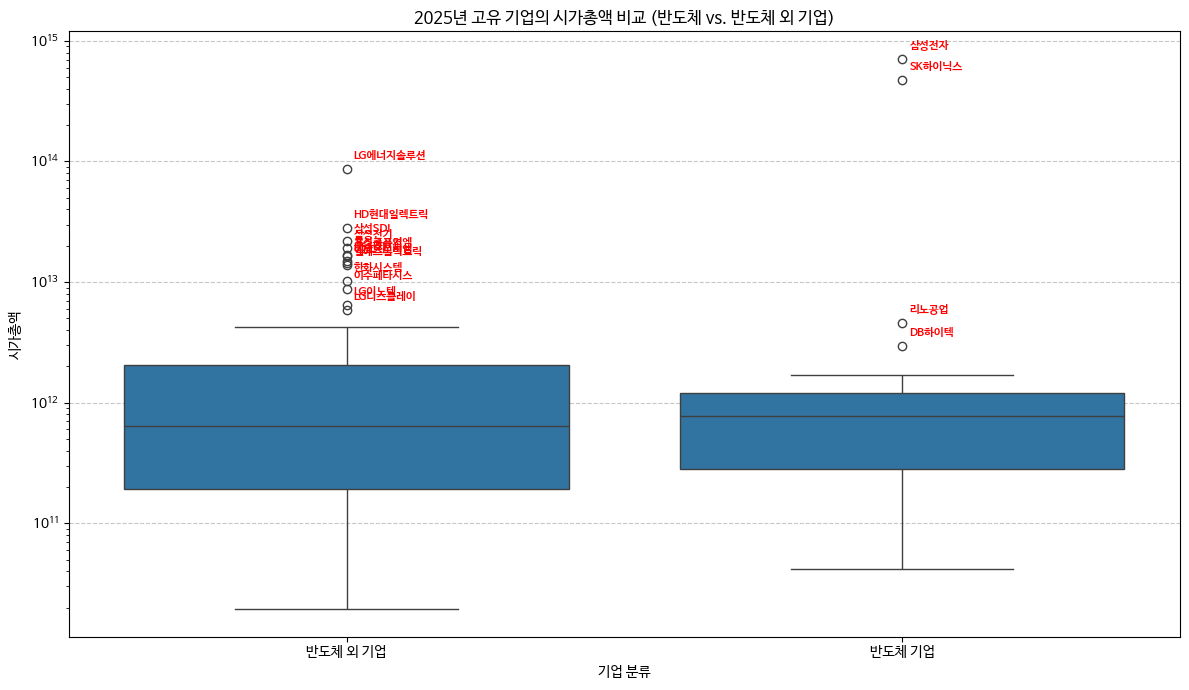

In [37]:
import numpy as np

# 시가총액 박스 플롯 생성 (정제된 데이터 사용)

if not companies_2025_cleaned.empty:
    plt.figure(figsize=(12, 7)) # Adjust figure size for annotations
    ax = sns.boxplot(x='반도체 여부', y='시가총액', data=companies_2025_cleaned)
    plt.title('2025년 고유 기업의 시가총액 비교 (반도체 vs. 반도체 외 기업)')
    plt.xlabel('기업 분류')
    plt.ylabel('시가총액')
    plt.yscale('log') # 시가총액의 스케일 차이가 클 경우 로그 스케일 적용
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 아웃라이어 기업명 표시
    # 각 그룹별 IQR 및 아웃라이어 경계 계산
    for i, category in enumerate(['반도체 외 기업', '반도체 기업']):
        # 해당 카테고리의 시가총액 데이터만 선택
        subset = companies_2025_cleaned[companies_2025_cleaned['반도체 여부'] == category]['시가총액']

        # NaN 값이 있으면 quantile 계산이 안되므로 제거
        subset = subset.dropna()

        if not subset.empty:
            Q1 = subset.quantile(0.25)
            Q3 = subset.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # 해당 카테고리 내에서 아웃라이어에 해당하는 기업 필터링
            outliers = companies_2025_cleaned[
                (companies_2025_cleaned['반도체 여부'] == category) &
                ((companies_2025_cleaned['시가총액'] < lower_bound) | (companies_2025_cleaned['시가총액'] > upper_bound))
            ]

            # 아웃라이어 기업명 표기
            for _, row in outliers.iterrows():
                # x_pos는 '반도체 외 기업'이면 0, '반도체 기업'이면 1 (seaborn boxplot의 기본 순서)
                x_pos = i
                y_pos = row['시가총액']
                company_name = row['기업명']

                # 텍스트가 겹치지 않도록 약간의 오프셋을 줄 수 있음
                ax.annotate(company_name, (x_pos, y_pos),
                            textcoords="offset points", # how to position the text
                            xytext=(5,5), # distance from text to points (x,y)
                            ha='left', va='bottom', # horizontal alignment, vertical alignment
                            fontsize=8, color='red', weight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("플롯을 그릴 유효한 시가총액 데이터가 충분하지 않습니다.")

## 등급 개선 후보 선정 및 시각화

'통합 등급'은 'ESG등급'을 기준으로 하며, 등급 개선을 정량적으로 측정하기 위해 각 ESG 등급에 숫자를 매겨 계산합니다.

**등급-숫자 매핑:**
*   A+: 6
*   A: 5
*   B+: 4
*   B: 3
*   C: 2
*   D: 1

이후 각 기업의 연도별 등급 변화를 계산하여 개선 정도를 파악하고, 각 카테고리(전체, 반도체, 비반도체)별 상위 5개 개선 기업의 등급 변화 추이를 시각화합니다.

In [38]:
# 1. ESG 등급을 숫자로 매핑 (높은 숫자가 좋은 등급)
grade_to_numeric = {'A+': 6, 'A': 5, 'B+': 4, 'B': 3, 'C': 2, 'D': 1}
numeric_to_grade = {v: k for k, v in grade_to_numeric.items()} # plotting용 역매핑

# DF에 'ESG_numerical' 컬럼 추가
DF['ESG_numerical'] = DF['ESG등급'].map(grade_to_numeric)

# 2. 기업별 연도별 ESG 등급 변화 계산
# '기업코드'와 '평가년도'로 정렬
temp_df_for_changes = DF.sort_values(by=['기업코드', '평가년도']).copy()

# 기업별 ESG_numerical의 차이 계산 (이전 연도 대비)
temp_df_for_changes['ESG_numerical_diff'] = temp_df_for_changes.groupby('기업코드')['ESG_numerical'].diff()

# 3. 각 기업의 최대 등급 개선 폭 찾기
# 긍정적인 변화(개선)만 고려하여 최대 개선 폭 추출
max_improvements_per_company = temp_df_for_changes[temp_df_for_changes['ESG_numerical_diff'] > 0] \
                               .groupby(['기업코드', '기업명'])['ESG_numerical_diff'].max() \
                               .reset_index() \
                               .sort_values(by='ESG_numerical_diff', ascending=False)

print("기업별 최대 등급 개선 폭 (상위 10개):")
display(max_improvements_per_company.head(10))

기업별 최대 등급 개선 폭 (상위 10개):


,기업코드,기업명,ESG_numerical_diff
2,990,DB하이텍,2.0
13,9450,경동나비엔,2.0
20,20150,롯데에너지머티리얼즈,2.0
31,61970,LB세미콘,2.0
33,78600,대주전자재료,2.0
49,272290,이녹스첨단소재,2.0
39,166090,하나머티리얼즈,2.0
46,247540,에코프로비엠,2.0
45,222800,심텍,2.0
47,248070,솔루엠,2.0


In [39]:
# 4. 각 카테고리별 상위 5개 개선 기업 선정

# 4-1. 전체 기업 중 상위 5개 개선 기업
top_5_overall_codes = max_improvements_per_company['기업코드'].head(5).tolist()
print(f"\n전체 기업 중 등급 개선 상위 5개 기업 코드: {top_5_overall_codes}")

# 4-2. 반도체 기업 중 상위 5개 개선 기업
# unique_semiconductor_기업코드 (이전 셀에서 정의됨) 사용
top_5_semiconductor_codes = max_improvements_per_company[
    max_improvements_per_company['기업코드'].isin(unique_semiconductor_기업코드)
]['기업코드'].head(5).tolist()
print(f"반도체 기업 중 등급 개선 상위 5개 기업 코드: {top_5_semiconductor_codes}")

# 4-3. 비반도체 기업 중 상위 5개 개선 기업
# unique_semiconductor_기업코드에 없는 기업 필터링
top_5_non_semiconductor_codes = max_improvements_per_company[
    ~max_improvements_per_company['기업코드'].isin(unique_semiconductor_기업코드)
]['기업코드'].head(5).tolist()
print(f"비반도체 기업 중 등급 개선 상위 5개 기업 코드: {top_5_non_semiconductor_codes}")


전체 기업 중 등급 개선 상위 5개 기업 코드: [990, 9450, 20150, 61970, 78600]
반도체 기업 중 등급 개선 상위 5개 기업 코드: [990, 166090, 5930, 660, 17900]
비반도체 기업 중 등급 개선 상위 5개 기업 코드: [9450, 20150, 61970, 78600, 272290]


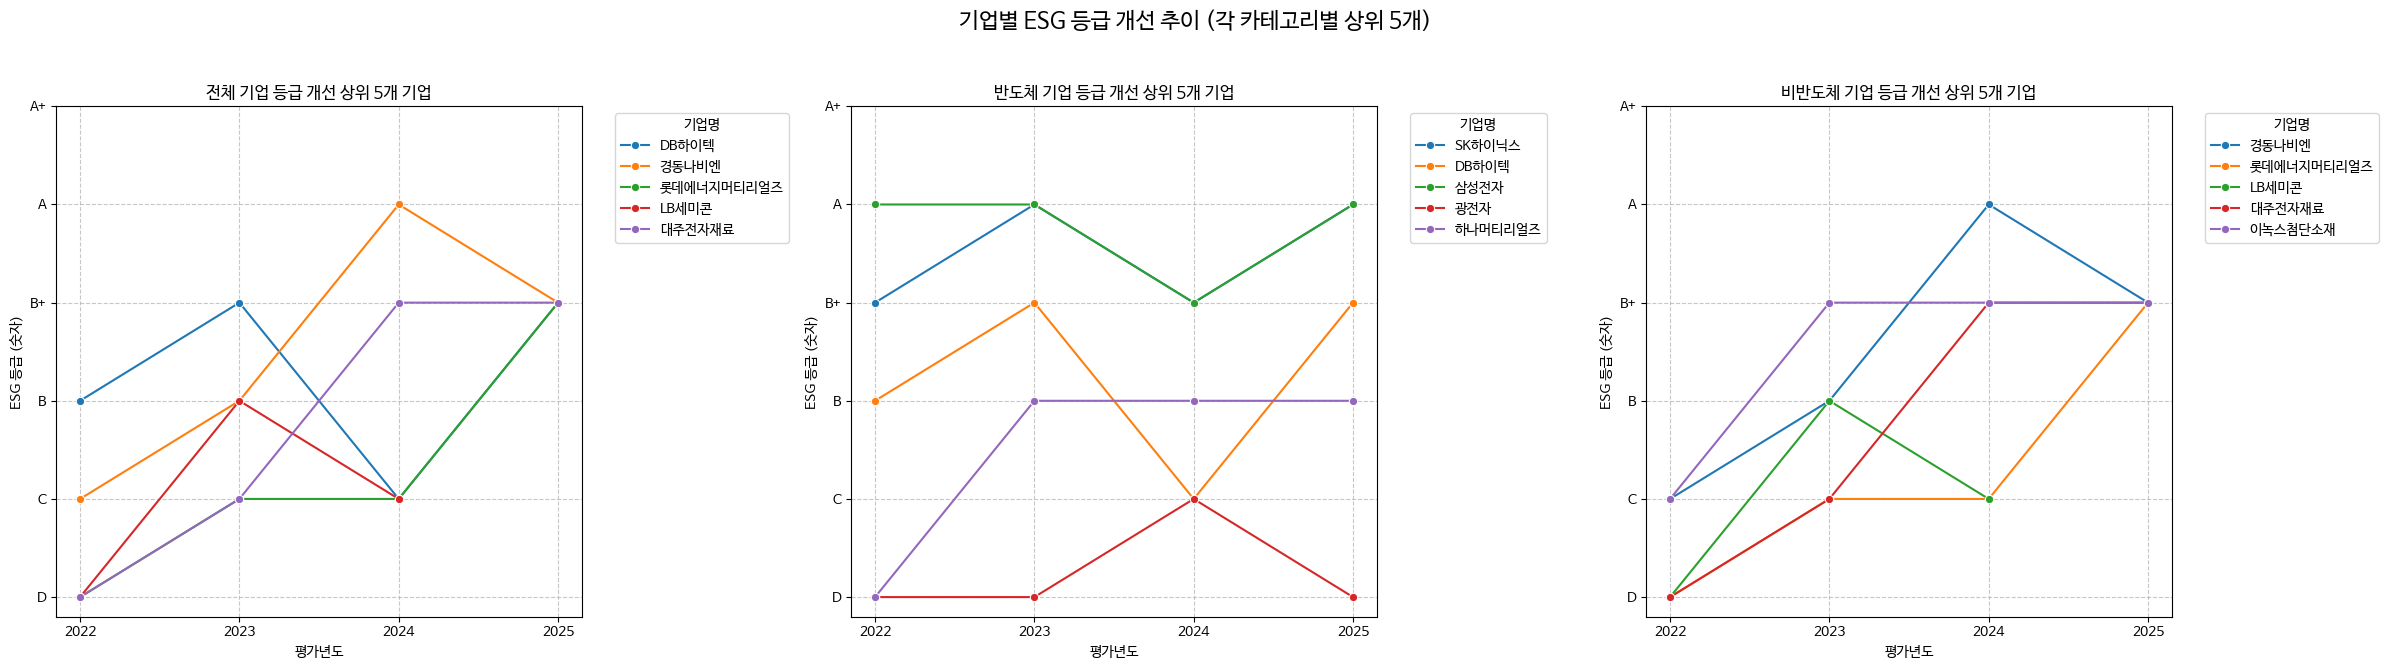

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5. 등급 개선 추이 시각화
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=False) # y축 스케일이 다를 수 있으므로 sharey=False
fig.suptitle('기업별 ESG 등급 개선 추이 (각 카테고리별 상위 5개)', fontsize=16)

plot_data_dict = {
    '전체 기업': top_5_overall_codes,
    '반도체 기업': top_5_semiconductor_codes,
    '비반도체 기업': top_5_non_semiconductor_codes
}

for i, (title, codes) in enumerate(plot_data_dict.items()):
    ax = axes[i]
    if codes:
        # 해당 기업들의 전체 기간 데이터 필터링
        filtered_df = DF[DF['기업코드'].isin(codes)].sort_values(by=['기업코드', '평가년도'])

        # 시각화
        sns.lineplot(data=filtered_df, x='평가년도', y='ESG_numerical', hue='기업명', marker='o', ax=ax)
        ax.set_title(f'{title} 등급 개선 상위 5개 기업')
        ax.set_xlabel('평가년도')
        ax.set_ylabel('ESG 등급 (숫자)')
        ax.set_xticks(filtered_df['평가년도'].unique())
        ax.set_yticks(list(grade_to_numeric.values()))
        ax.set_yticklabels([numeric_to_grade[y] for y in ax.get_yticks()])
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(title='기업명', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.text(0.5, 0.5, '데이터 없음', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title(f'{title} 등급 개선 상위 5개 기업')
        ax.set_xlabel('평가년도')
        ax.set_ylabel('ESG 등급 (숫자)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

In [41]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os

# 한글 폰트 설치 및 설정
!apt-get update -qq > /dev/null
!apt-get install fonts-nanum -qq > /dev/null

# 폰트 캐시 재구성 및 폰트 매니저에 추가
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for fpath in font_files:
    fm.fontManager.addfont(fpath)

# 폰트 설정 적용
plt.rc('font', family='NanumBarunGothic') # 시스템에 설치된 나눔바른고딕 사용
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

print("한글 폰트 설정 완료: NanumBarunGothic")

# DF의 '평가년도' 컬럼을 정수형으로 변환 (혹시 모를 타입 불일치 방지)
DF['평가년도'] = DF['평가년도'].astype(int)

# 2025년 데이터 필터링 (DF 기준, 기업코드 중복 제거)
companies_2025 = DF[DF['평가년도'] == 2025].drop_duplicates(subset=['기업코드']).copy()

# 2025년 데이터가 있는지 확인
if companies_2025.empty:
    print(f"경고: 2025년 데이터가 없습니다. 현재 DF에 존재하는 평가년도: {DF['평가년도'].unique()}")
    print("2025년 데이터가 없으므로 박스 플롯을 그릴 수 없습니다.")
else:
    print(f"2025년 데이터 ({len(companies_2025)}개 기업) 필터링 완료.")
    print("2025년 데이터의 첫 5개 행:")
    display(companies_2025.head())

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
한글 폰트 설정 완료: NanumBarunGothic
2025년 데이터 (89개 기업) 필터링 완료.
2025년 데이터의 첫 5개 행:


,기업명,기업코드,평가년도,ESG등급,환경,사회,지배구조,시장구분,산업코드,시가총액,지속가능경영보고서_발행,기업지배구조보고서_발행,보고서_발행_유형,ESG_numerical
3,가온전선,500,2025,B+,A,A+,B,KOSPI,C28302,1.363150e+12,1,1,둘 다 발행,4
7,경동나비엔,9450,2025,B+,A,A+,B,KOSPI,C28520,8.085570e+11,1,1,둘 다 발행,4
11,경인전자,9140,2025,D,D,D,D,KOSPI,C2629,3.220134e+10,0,0,미발행,1
15,광명전기,17040,2025,D,C,D,D,KOSPI,C28123,5.347862e+10,1,0,지속가능경영만,1
19,광전자,17900,2025,D,C,D,D,KOSPI,C2612,1.044150e+11,0,0,미발행,1


In [42]:
# '시가총액'이 NaN인 행 제거 및 숫자형으로 변환
companies_2025_cleaned = companies_2025.dropna(subset=['시가총액']).copy()
companies_2025_cleaned['시가총액'] = pd.to_numeric(companies_2025_cleaned['시가총액'])

# '반도체 기업' 여부 컬럼 추가
companies_2025_cleaned['반도체 여부'] = companies_2025_cleaned['기업코드'].isin(unique_semiconductor_기업코드).map({True: '반도체 기업', False: '반도체 외 기업'})

print(f"시가총액이 있는 2025년 데이터 (플롯용): {len(companies_2025_cleaned)}개 기업")
if companies_2025_cleaned.empty:
    print("경고: 시가총액 데이터가 없어 박스 플롯을 그릴 수 없습니다.")
else:
    print("플롯을 그릴 데이터의 첫 5개 행:")
    display(companies_2025_cleaned.head())

시가총액이 있는 2025년 데이터 (플롯용): 89개 기업
플롯을 그릴 데이터의 첫 5개 행:


,기업명,기업코드,평가년도,ESG등급,환경,사회,지배구조,시장구분,산업코드,시가총액,지속가능경영보고서_발행,기업지배구조보고서_발행,보고서_발행_유형,ESG_numerical,반도체 여부
3,가온전선,500,2025,B+,A,A+,B,KOSPI,C28302,1.363150e+12,1,1,둘 다 발행,4,반도체 외 기업
7,경동나비엔,9450,2025,B+,A,A+,B,KOSPI,C28520,8.085570e+11,1,1,둘 다 발행,4,반도체 외 기업
11,경인전자,9140,2025,D,D,D,D,KOSPI,C2629,3.220134e+10,0,0,미발행,1,반도체 외 기업
15,광명전기,17040,2025,D,C,D,D,KOSPI,C28123,5.347862e+10,1,0,지속가능경영만,1,반도체 외 기업
19,광전자,17900,2025,D,C,D,D,KOSPI,C2612,1.044150e+11,0,0,미발행,1,반도체 기업


## 코스피/코스닥 시장별 반도체/비반도체 기업 분류

이전에 추출한 고유 기업 목록(`unique_companies`)을 사용하여, '시장구분'(`시장구분`)에 따라 코스피와 코스닥 기업을 나눈 후, 각각 반도체 기업 여부를 재분류합니다.

In [43]:
# 1. 코스피 기업 분류
kospi_companies = unique_companies[unique_companies['시장구분'] == 'KOSPI'].copy()
kospi_semiconductor_count = kospi_companies['기업코드'].isin(unique_semiconductor_기업코드).sum()
kospi_non_semiconductor_count = len(kospi_companies) - kospi_semiconductor_count

print("--- 코스피 기업 분류 ---")
print(f"총 코스피 고유 기업 수: {len(kospi_companies)}개")
print(f"코스피 반도체 기업 수: {kospi_semiconductor_count}개")
print(f"코스피 비반도체 기업 수: {kospi_non_semiconductor_count}개")

# 2. 코스닥 기업 분류
kosdaq_companies = unique_companies[unique_companies['시장구분'] == 'KOSDAQ'].copy()
kosdaq_semiconductor_count = kosdaq_companies['기업코드'].isin(unique_semiconductor_기업코드).sum()
kosdaq_non_semiconductor_count = len(kosdaq_companies) - kosdaq_semiconductor_count

print("\n--- 코스닥 기업 분류 ---")
print(f"총 코스닥 고유 기업 수: {len(kosdaq_companies)}개")
print(f"코스닥 반도체 기업 수: {kosdaq_semiconductor_count}개")
print(f"코스닥 비반도체 기업 수: {kosdaq_non_semiconductor_count}개")

# 결과를 데이터프레임으로 정리하여 출력
classification_data = {
    '시장구분': ['KOSPI', 'KOSPI', 'KOSDAQ', 'KOSDAQ'],
    '기업 분류': ['반도체 기업', '비반도체 기업', '반도체 기업', '비반도체 기업'],
    '개수': [kospi_semiconductor_count, kospi_non_semiconductor_count, kosdaq_semiconductor_count, kosdaq_non_semiconductor_count]
}
classification_df = pd.DataFrame(classification_data)

print("\n--- 시장별 반도체/비반도체 기업 분류 요약 ---")
display(classification_df)

--- 코스피 기업 분류 ---
총 코스피 고유 기업 수: 63개
코스피 반도체 기업 수: 10개
코스피 비반도체 기업 수: 53개

--- 코스닥 기업 분류 ---
총 코스닥 고유 기업 수: 29개
코스닥 반도체 기업 수: 10개
코스닥 비반도체 기업 수: 19개

--- 시장별 반도체/비반도체 기업 분류 요약 ---


,시장구분,기업 분류,개수
0,KOSPI,반도체 기업,10
1,KOSPI,비반도체 기업,53
2,KOSDAQ,반도체 기업,10
3,KOSDAQ,비반도체 기업,19


# K MEANS CLUSTERING 으로 집단 분류


이 스크립트는 등급 수준·변동성·추세·규모·업종·시장구분·데이터완전성을 모두 표준화된 피처로 만들어 KMeans로 5개 클러스터로 나누고, 각 클러스터 중심에 가장 가까운 기업을 대표로 뽑는 방식입니다. 클러스터가 서로 다른 "성격"을 가지므로 결과적으로 최대한 이질적인 5개 기업이 뽑힙니다. 스크립트 하단에는 클러스터링 대신 조건 필터링으로 수동 선정할 때 참고할 5가지 케이스 예시(반도체+개선/비반도체+하락/데이터부족/급변동/서브점수 편차 큰 기업)도 적어뒀습니다.

업종(5개 서로 다른 산업코드), 시장구분(KOSPI 3 / KOSDAQ 2), 규모(대형~소형 고르게 분포), 반도체 여부(1개는 반도체 포함) 축에서는 다양성이 잘 확보됐는데, 등급 수준은 "낮음" 쪽에 좀 몰려있고 추세도 대부분 "안정"이라 살짝 아쉬운 조합입니다.

이건 랜덤시드(random_state=42)에 따라 클러스터 배치가 달라질 수 있고, 또 어떤 피처에 가중치를 더 둘지(예: 등급수준 다양성을 더 강제하고 싶다든지)에 따라서도 결과가 바뀝니다.

1. Elbow plot — k=2→5로 갈 때 이너셔가 크게 꺾이고 그 이후론 완만해져서, k=5가 과도하게 무리한 선택은 아니라는 걸 확인할 수 있습니다.

2. PCA 2D 산점도 — 92개 기업을 2차원(설명분산 52%)에 투영하고, 선택된 5개 대표기업을 검은 테두리로 표시했습니다. 다만 보시면 시그네틱스/에스피지/아남전자가 왼쪽 아래에 몰려 있어서 시각적으로는 그렇게까지 "떨어져" 보이지 않는데, 이는 PCA가 8개 피처를 2개 축으로 압축하는 과정에서 정보 손실이 있기 때문입니다 (설명분산 52%면 나머지 48%는 이 그림에 안 보이는 차이).

3. 클러스터 프로파일 히트맵 (표준화 값 기준) — 각 클러스터가 실제로 "어떤 축에서" 다른지 보여줍니다.

클러스터 0(LG디스플레이): 등급평균 높음 + 시가총액 큼 + 보고서발행 많음 → 우량 대형주
클러스터 3(시그네틱스): 반도체여부 압도적으로 높음(1.90) → 반도체 특화
클러스터 2(에스피지): 연도수 -2.73으로 극단적 → 데이터 연도 적은 기업
클러스터 4(한국단자공업): 등급변동성·등급추세 높음 → 등급 변화가 큰 기업
클러스터 1(아남전자): 전반적으로 다 낮음 → 소형·저평가·데이터 빈약형

PCA 그림보다는 이 히트맵이 "왜 이 5개가 서로 다른지"를 실질적으로 더 잘 설명해줍니다.

=== 클러스터별 대표(다양성 확보) 5개 기업 ===
    기업명  기업코드   산업코드   시장구분  등급평균  등급추세  반도체여부    로그시가총액
LG디스플레이 34220  C2621  KOSPI  4.50     0      0 29.406821
   아남전자  8700   C265  KOSPI  1.00     0      0 25.344811
   에스피지 58610 C28111 KOSDAQ  1.00     0      0 28.220484
  시그네틱스 33170  C2612 KOSDAQ  1.25     0      1 24.928549
 한국단자공업 25540  C2812  KOSPI  2.00     2      0 27.246446


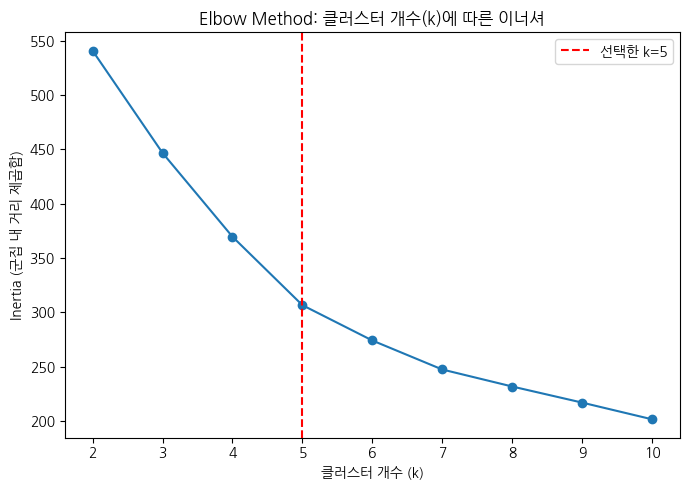

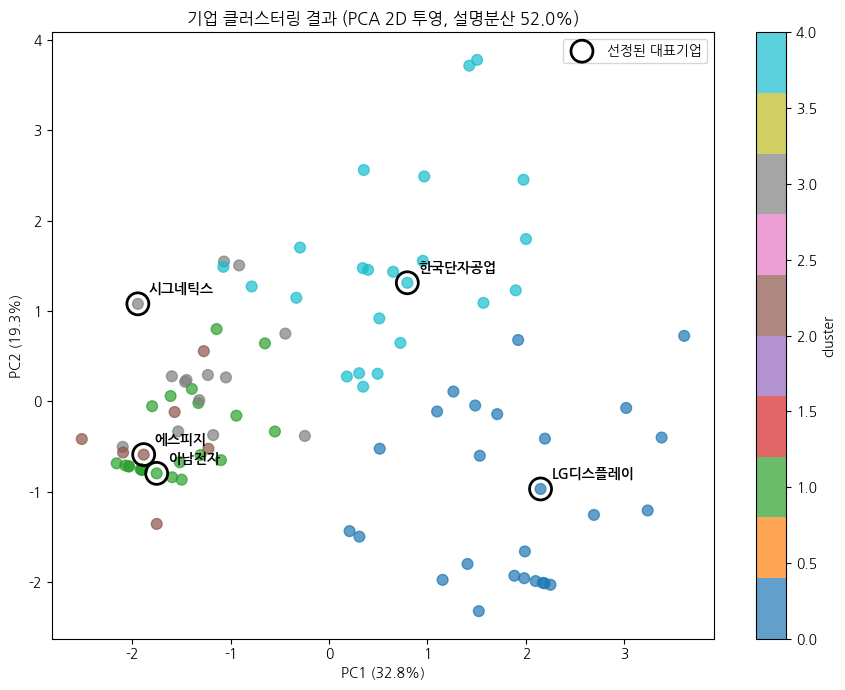

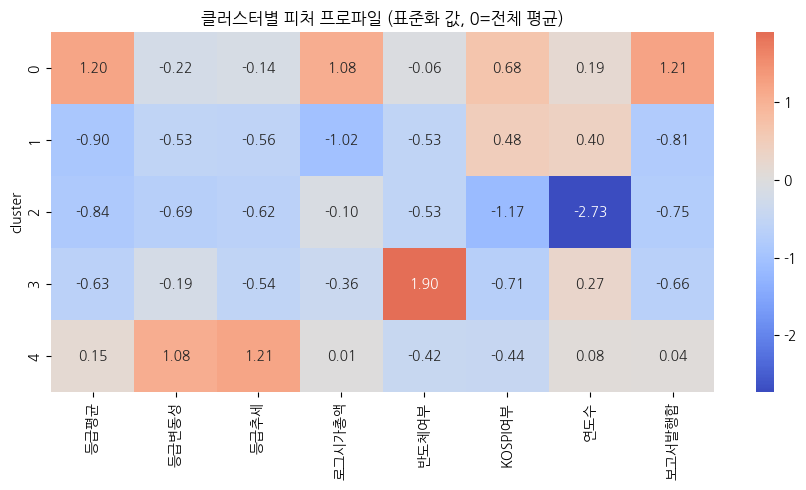


저장된 그래프: elbow_plot.png / cluster_pca_scatter.png / cluster_profile_heatmap.png


In [50]:
"""
다양한 5개 기업 선정 스크립트
- 여러 축(산업, 시장, 규모, 등급추세, 데이터완전성)을 피처로 표준화한 뒤
  KMeans로 클러스터링하여 클러스터별 대표 기업 1개씩 추출
- 클러스터 개수 = 원하는 선정 기업 수(5)로 설정하면
  "서로 최대한 다른" 기업 5개를 자동으로 뽑을 수 있음
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ---------------------------------------------------------
# 1. 데이터 로드 & 기본 전처리
# ---------------------------------------------------------
EDA_FILE_PATH = '/content/drive/MyDrive/프로젝트/EDA용 파일.xlsx'
SEMICONDUCTOR_LIST_PATH = '/content/drive/MyDrive/프로젝트/반도체 list.xlsx'

df = pd.read_excel(EDA_FILE_PATH)

grade_map = {'A+': 6, 'A': 5, 'B+': 4, 'B': 3, 'C': 2, 'D': 1}
df['ESG_num'] = df['ESG등급'].map(grade_map)

semiconductor_codes = pd.read_excel(SEMICONDUCTOR_LIST_PATH)['기업코드'].unique()
# ※ 반도체_list.xlsx는 컬럼 밀림 이슈가 있으니 '기업코드'만 신뢰하고
#    다른 컬럼은 고치기 전까지 사용하지 말 것

# ---------------------------------------------------------
# 2. 기업 단위로 피처 집계
# ---------------------------------------------------------
agg = df.sort_values(['기업코드', '평가년도']).groupby('기업코드').agg(
    기업명=('기업명', 'first'),
    산업코드=('산업코드', 'first'),
    시장구분=('시장구분', 'first'),
    연도수=('평가년도', 'nunique'),
    등급평균=('ESG_num', 'mean'),
    등급변동성=('ESG_num', 'std'),
    최신등급=('ESG_num', 'last'),
    최근시가총액=('시가총액', 'last'),
    보고서발행합=('지속가능경영보고서_발행', 'sum'),  # 4개년 중 발행한 횟수
).reset_index()

# 등급 추세(최근 - 최초) : 양수=개선, 음수=하락, 0=안정
first_grade = df.sort_values(['기업코드', '평가년도']).groupby('기업코드')['ESG_num'].first()
agg['등급추세'] = agg['최신등급'] - agg.set_index('기업코드').index.map(first_grade).values

agg['반도체여부'] = agg['기업코드'].isin(semiconductor_codes).astype(int)
agg['등급변동성'] = agg['등급변동성'].fillna(0)
agg['최근시가총액'] = agg['최근시가총액'].fillna(agg['최근시가총액'].median())
agg['로그시가총액'] = np.log1p(agg['최근시가총액'])

# 시장구분 더미화
agg['KOSPI여부'] = (agg['시장구분'] == 'KOSPI').astype(int)

# ---------------------------------------------------------
# 3. 클러스터링용 피처 선택 & 표준화
# ---------------------------------------------------------
feature_cols = ['등급평균', '등급변동성', '등급추세', '로그시가총액',
                 '반도체여부', 'KOSPI여부', '연도수', '보고서발행합']

X = agg[feature_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

# ---------------------------------------------------------
# 4. KMeans로 5개 클러스터 생성 → 클러스터 중심에 가장 가까운 기업을 대표로 선정
# ---------------------------------------------------------
N_SELECT = 5
km = KMeans(n_clusters=N_SELECT, random_state=42, n_init=10)
agg['cluster'] = km.fit_predict(X_scaled)

selected = []
for c in range(N_SELECT):
    idx = np.where(agg['cluster'] == c)[0]
    center = km.cluster_centers_[c]
    dists = np.linalg.norm(X_scaled[idx] - center, axis=1)
    rep_idx = idx[np.argmin(dists)]
    selected.append(agg.iloc[rep_idx])

selected_df = pd.DataFrame(selected)
print("=== 클러스터별 대표(다양성 확보) 5개 기업 ===")
print(selected_df[['기업명', '기업코드', '산업코드', '시장구분',
                    '등급평균', '등급추세', '반도체여부', '로그시가총액']].to_string(index=False))

# ---------------------------------------------------------
# 5. 시각화 (1) Elbow method - 클러스터 개수 타당성 확인
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (환경에 따라 설치된 폰트명이 다를 수 있어 후보를 순서대로 탐색)
font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic',
                   'Noto Sans CJK KR', 'Noto Sans CJK JP']  # ttc 폰트는 matplotlib에 대표 이름(JP)으로만 등록되는 경우가 있음
available_fonts = {f.name for f in fm.fontManager.ttflist}
for name in font_candidates:
    if name in available_fonts:
        plt.rc('font', family=name)
        break
plt.rcParams['axes.unicode_minus'] = False

inertias = []
k_range = range(2, 11)
for k in k_range:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km_k.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(k_range), inertias, marker='o')
plt.axvline(N_SELECT, color='red', linestyle='--', label=f'선택한 k={N_SELECT}')
plt.title('Elbow Method: 클러스터 개수(k)에 따른 이너셔')
plt.xlabel('클러스터 개수 (k)')
plt.ylabel('Inertia (군집 내 거리 제곱합)')
plt.legend()
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()
plt.close()

# ---------------------------------------------------------
# 6. 시각화 (2) PCA로 2차원 축소 후 클러스터 산점도 + 대표기업 라벨
# ---------------------------------------------------------
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
agg['pca1'] = X_pca[:, 0]
agg['pca2'] = X_pca[:, 1]

plt.figure(figsize=(9, 7))
scatter = plt.scatter(agg['pca1'], agg['pca2'], c=agg['cluster'], cmap='tab10', s=60, alpha=0.7)

# 클러스터 중심(대표기업) 강조 표시
sel_codes = selected_df['기업코드'].tolist()
rep_points = agg[agg['기업코드'].isin(sel_codes)]
plt.scatter(rep_points['pca1'], rep_points['pca2'],
            facecolors='none', edgecolors='black', s=250, linewidths=2, label='선정된 대표기업')

for _, row in rep_points.iterrows():
    plt.annotate(row['기업명'], (row['pca1'], row['pca2']),
                 textcoords="offset points", xytext=(8, 8), fontsize=10, fontweight='bold')

plt.title(f'기업 클러스터링 결과 (PCA 2D 투영, 설명분산 {pca.explained_variance_ratio_.sum():.1%})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend()
plt.colorbar(scatter, label='cluster')
plt.tight_layout()
plt.savefig('cluster_pca_scatter.png', dpi=150)
plt.show()
plt.close()

# ---------------------------------------------------------
# 7. 시각화 (3) 피처별 클러스터 프로파일 히트맵 (어떤 축에서 다양한지 한눈에 확인)
# ---------------------------------------------------------
import seaborn as sns

# 원본 스케일(raw)로 그리면 시가총액처럼 값 범위가 큰 피처가 색상을 지배해버리므로,
# 클러스터링에 실제 사용한 표준화(z-score) 값 기준으로 프로파일을 그림
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df['cluster'] = agg['cluster'].values
cluster_profile = X_scaled_df.groupby('cluster')[feature_cols].mean()

plt.figure(figsize=(9, 5))
sns.heatmap(cluster_profile, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('클러스터별 피처 프로파일 (표준화 값, 0=전체 평균)')
plt.tight_layout()
plt.savefig('cluster_profile_heatmap.png', dpi=150)
plt.show()
plt.close()

print("\n저장된 그래프: elbow_plot.png / cluster_pca_scatter.png / cluster_profile_heatmap.png")

# ---------------------------------------------------------
# 참고: 클러스터링 대신 수동 매트릭스 방식으로 뽑고 싶다면
# 아래처럼 조건별 필터링 후 눈으로 골라도 됨
# ---------------------------------------------------------
# ex1) 반도체 + 등급 개선 + KOSDAQ 소형주
# ex2) 비반도체 + 등급 하락 + KOSPI 대형주
# ex3) 등급 완전 안정 + 보고서 미발행 (데이터 부족 케이스)
# ex4) 등급 급변동(std 최상위) 기업
# ex5) 서브점수(E/S/G) 편차가 가장 큰 기업

[참고] 클러스터링 대상 표본 수: 92개 (표본이 작아 지표가 불안정할 수 있음)

=== k별 클러스터링 품질 지표 비교 ===
  k  Silhouette↑  DaviesBouldin↓  CalinskiHarabasz↑
  2        0.252           1.598               32.5
  3        0.249           1.459               28.8
  4        0.280           1.375               29.1
  5        0.310           1.148               30.5 <- 선택한 k
  6        0.310           1.259               29.0
  7        0.317           1.267               28.0
  8        0.297           1.198               26.1
  9        0.304           1.197               24.8
 10        0.307           1.119               24.2


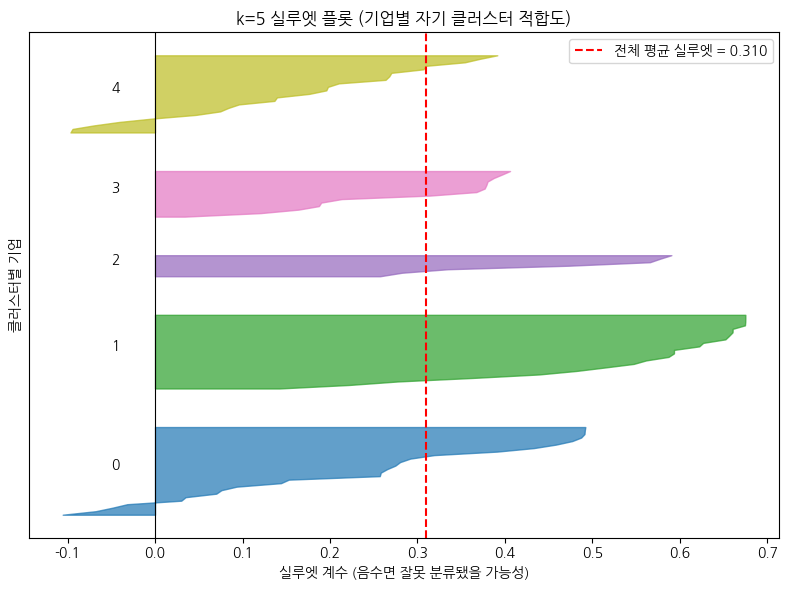


실루엣 값이 음수인 기업 9개 (군집 경계가 모호할 수 있음):
     기업명  cluster       실루엣
  한솔테크닉스        4 -0.094313
 DN오토모티브        0 -0.105564
  코리아써키트        4 -0.070207
   인터플렉스        4 -0.040817
    비에이치        4 -0.096710
    일진전기        0 -0.048673
   서진시스템        4 -0.001379
    대덕전자        0 -0.067919
LG에너지솔루션        0 -0.031779

=== 안정성 검증: 서로 다른 random_state 간 군집 일치도(ARI) ===
서로 다른 seed 쌍 간 평균 ARI: 0.946 (1에 가까울수록 안정적)
최소 ARI: 0.854 / 최대 ARI: 1.000

KMeans vs 계층적 군집(Agglomerative) 간 ARI: 0.602 (1에 가까울수록 알고리즘이 달라도 같은 구조를 찾았다는 뜻)

저장된 그래프: silhouette_plot.png


In [51]:
"""
클러스터링 신뢰도 검증
- 이 셀은 select_diverse_companies.py를 먼저 실행해서
  X_scaled, agg, N_SELECT, KMeans, plt 등이 이미 메모리에 있는 상태에서
  이어서 실행하는 것을 전제로 함
"""

from sklearn.metrics import (silhouette_score, silhouette_samples,
                              davies_bouldin_score, calinski_harabasz_score,
                              adjusted_rand_score)
from sklearn.cluster import AgglomerativeClustering, KMeans
import matplotlib.cm as cm
import numpy as np

n_samples = X_scaled.shape[0]
print(f"[참고] 클러스터링 대상 표본 수: {n_samples}개 (표본이 작아 지표가 불안정할 수 있음)")

# ---------------------------------------------------------
# 1. 여러 k에 대해 3대 품질 지표 비교
# ---------------------------------------------------------
print("\n=== k별 클러스터링 품질 지표 비교 ===")
print(f"{'k':>3} {'Silhouette↑':>12} {'DaviesBouldin↓':>15} {'CalinskiHarabasz↑':>18}")
for k in range(2, 11):
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    labels_k = km_k.labels_
    sil = silhouette_score(X_scaled, labels_k)
    dbi = davies_bouldin_score(X_scaled, labels_k)
    ch = calinski_harabasz_score(X_scaled, labels_k)
    marker = ' <- 선택한 k' if k == N_SELECT else ''
    print(f"{k:>3} {sil:>12.3f} {dbi:>15.3f} {ch:>18.1f}{marker}")

# 해석 기준:
#  - Silhouette: -1~1, 클수록 좋음(0.5 이상 양호, 0.25 이하면 군집 구조가 약함)
#  - Davies-Bouldin: 0 이상, 작을수록 좋음(군집 간 분리가 잘 됨)
#  - Calinski-Harabasz: 클수록 좋음(군집 내 응집 대비 군집 간 분리 비율)

# ---------------------------------------------------------
# 2. 실루엣 상세 플롯 (기업 단위로 잘 분류됐는지 시각 확인)
# ---------------------------------------------------------
labels_final = agg['cluster'].values
sil_values = silhouette_samples(X_scaled, labels_final)
sil_avg = silhouette_score(X_scaled, labels_final)

plt.figure(figsize=(8, 6))
y_lower = 10
for c in range(N_SELECT):
    c_sil = np.sort(sil_values[labels_final == c])
    size_c = c_sil.shape[0]
    y_upper = y_lower + size_c
    color = cm.tab10(c / N_SELECT)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil, facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_c, str(c))
    y_lower = y_upper + 10

plt.axvline(sil_avg, color='red', linestyle='--', label=f'전체 평균 실루엣 = {sil_avg:.3f}')
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'k={N_SELECT} 실루엣 플롯 (기업별 자기 클러스터 적합도)')
plt.xlabel('실루엣 계수 (음수면 잘못 분류됐을 가능성)')
plt.ylabel('클러스터별 기업')
plt.yticks([])
plt.legend()
plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150)
plt.show()

# 음수 실루엣(오분류 가능성 있는 기업) 확인
neg_idx = np.where(sil_values < 0)[0]
if len(neg_idx) > 0:
    print(f"\n실루엣 값이 음수인 기업 {len(neg_idx)}개 (군집 경계가 모호할 수 있음):")
    print(agg.iloc[neg_idx][['기업명', 'cluster']].assign(실루엣=sil_values[neg_idx]).to_string(index=False))
else:
    print("\n실루엣 값이 음수인 기업 없음 (개별 기업 단위로는 군집 배정이 애매하지 않음).")

# ---------------------------------------------------------
# 3. 안정성(stability) 검증: random_state를 바꿔가며 반복 후 군집 배정 일치도 확인
# ---------------------------------------------------------
print("\n=== 안정성 검증: 서로 다른 random_state 간 군집 일치도(ARI) ===")
seeds = [0, 1, 2, 3, 4, 42, 100]
label_sets = [KMeans(n_clusters=N_SELECT, random_state=s, n_init=10).fit(X_scaled).labels_ for s in seeds]

ari_matrix = np.zeros((len(seeds), len(seeds)))
for i in range(len(seeds)):
    for j in range(len(seeds)):
        ari_matrix[i, j] = adjusted_rand_score(label_sets[i], label_sets[j])

ari_offdiag = ari_matrix[np.triu_indices(len(seeds), k=1)]
print(f"서로 다른 seed 쌍 간 평균 ARI: {ari_offdiag.mean():.3f} (1에 가까울수록 안정적)")
print(f"최소 ARI: {ari_offdiag.min():.3f} / 최대 ARI: {ari_offdiag.max():.3f}")

# ---------------------------------------------------------
# 4. 알고리즘 교차검증: 계층적 군집(Agglomerative)과 비교
# ---------------------------------------------------------
agg_cluster = AgglomerativeClustering(n_clusters=N_SELECT).fit(X_scaled)
ari_vs_hierarchical = adjusted_rand_score(labels_final, agg_cluster.labels_)
print(f"\nKMeans vs 계층적 군집(Agglomerative) 간 ARI: {ari_vs_hierarchical:.3f}"
      f" (1에 가까울수록 알고리즘이 달라도 같은 구조를 찾았다는 뜻)")

print("\n저장된 그래프: silhouette_plot.png")

1. k별 품질 지표 비교표 (Silhouette / Davies-Bouldin / Calinski-Harabasz)
k=5는 Silhouette 0.310, DBI 1.148로 k=2~4보다는 낫지만, k=6~7과는 거의 차이가 없습니다. 즉 "k=5가 명백히 최선"이라기보다는 "괜찮은 선택지 중 하나" 정도입니다. 참고로 Silhouette 0.310은 일반적 기준(0.5 이상 양호, 0.25 이하 구조 약함)으로 보면 경계선 수준입니다 — 군집이 뚜렷하게 갈리기보다는 다소 뭉개져 있다는 뜻입니다.

2. 실루엣 플롯(기업 단위)
92개 중 9개 기업이 음수 실루엣(한솔테크닉스, DN오토모티브, 코리아써키트, 인터플렉스, 비에이치, 일진전기, 서진시스템, 대덕전자, LG에너지솔루션) — 이 기업들은 자기 클러스터보다 다른 클러스터에 더 가까울 수 있다는 뜻입니다. 클러스터 0과 4가 상대적으로 음수 실루엣 기업이 많아 경계가 흐릿한 편입니다.

3. 안정성 검증 (seed 바꿔가며 반복)
7개 다른 random_state로 반복했을 때 평균 ARI 0.946 (최소 0.854) — 이 정도면 꽤 안정적입니다. 즉 클러스터 배정 자체는 시드에 크게 흔들리지 않습니다.

4. 알고리즘 교차검증 (KMeans vs 계층적 군집)
ARI 0.602로, 방법을 바꾸면 결과가 꽤 달라집니다. 이건 "군집 구조 자체가 아주 견고하진 않다"는 신호입니다.

종합 판단: 안정성(seed)은 좋지만, 절대적인 군집 품질(Silhouette 0.31)과 알고리즘 간 일치도(ARI 0.60)를 보면 이 클러스터링을 "객관적으로 확실한 그룹 구조"라고 주장하긴 어렵습니다. 92개 표본에 8개 피처를 쓴 것도 표본 대비 차원이 많은 편이라 어느 정도 예견된 결과입니다. 실무적으로는 이 결과를 "완전히 검증된 그룹"보다는 "다양성을 강제하기 위한 보조 도구" 정도로 쓰고, 최종 5개 선정은 여기 나온 후보군 + 앞서 말씀드린 수동 매트릭스 기준(반도체/시장/등급추세/데이터완전성)을 같이 참고해서 확정하시는 걸 추천드립니다.

# 수동매트릭스



수동 매트릭스 기준 5개 기업 선정 + 시각화
- 클러스터링(select_diverse_companies.py)과 별개로,
  사람이 정한 5가지 기준 케이스에 맞춰 기업을 직접 선정
  ex1) 반도체 + 등급 개선 + KOSDAQ 소형주
  ex2) 비반도체 + 등급 하락 + KOSPI 대형주
  ex3) 등급 완전 안정 + 보고서 미발행 (데이터 부족 케이스)
  ex4) 등급 급변동(변동성 최상위) 기업
  ex5) E/S/G 서브점수 편차가 가장 큰 기업

In [53]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

EDA_FILE_PATH = '/content/drive/MyDrive/프로젝트/EDA용 파일.xlsx'
SEMICONDUCTOR_LIST_PATH = '/content/drive/MyDrive/프로젝트/반도체 list.xlsx'

# 한글 폰트 설정
font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic', 'Noto Sans CJK KR', 'Noto Sans CJK JP']
available_fonts = {f.name for f in fm.fontManager.ttflist}
for name in font_candidates:
    if name in available_fonts:
        plt.rc('font', family=name)
        break
plt.rcParams['axes.unicode_minus'] = False



규모티어 경계값: 소형 <= 333,015,333,333 < 중형 <= 1,396,776,666,667 < 대형

=== 수동 매트릭스 기준 5개 기업 선정 결과 ===
               선정기준     기업명   기업코드   산업코드   시장구분 규모티어  등급평균 등급추세     등급변동성    ESG_편차 반도체여부 데이터완전성
ex1_반도체·개선·KOSDAQ소형 하나머티리얼즈 166090  C2612 KOSDAQ   중형   2.5    2       1.0  2.516611  True     풍부
ex2_비반도체·하락·KOSPI대형   효성중공업 298040   C281  KOSPI   대형  4.25   -2  0.957427  2.645751 False     풍부
       ex3_안정·데이터부족    금호전기   1210 C28410  KOSPI   소형   1.0    0       0.0   0.57735 False    미발행
          ex4_등급급변동  대주전자재료  78600  C2629 KOSDAQ   중형  2.75    3       1.5       1.0 False     풍부
        ex5_ESG편차최대  이수페타시스   7660  C2622  KOSPI   대형   2.5    1   0.57735  2.516611 False     풍부


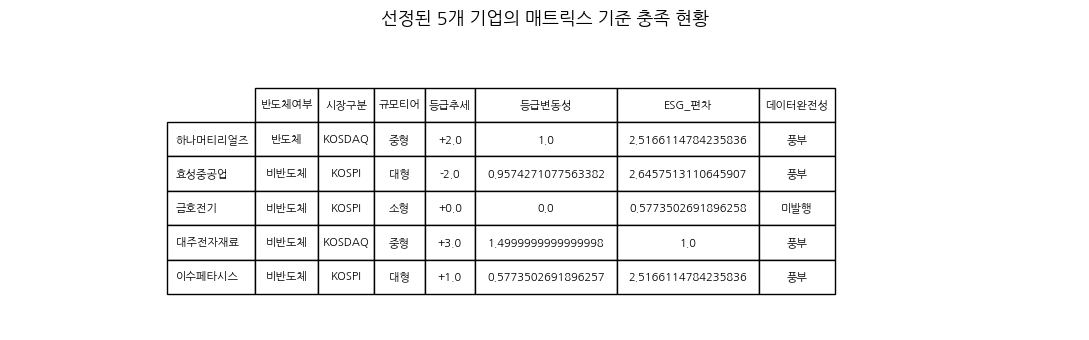

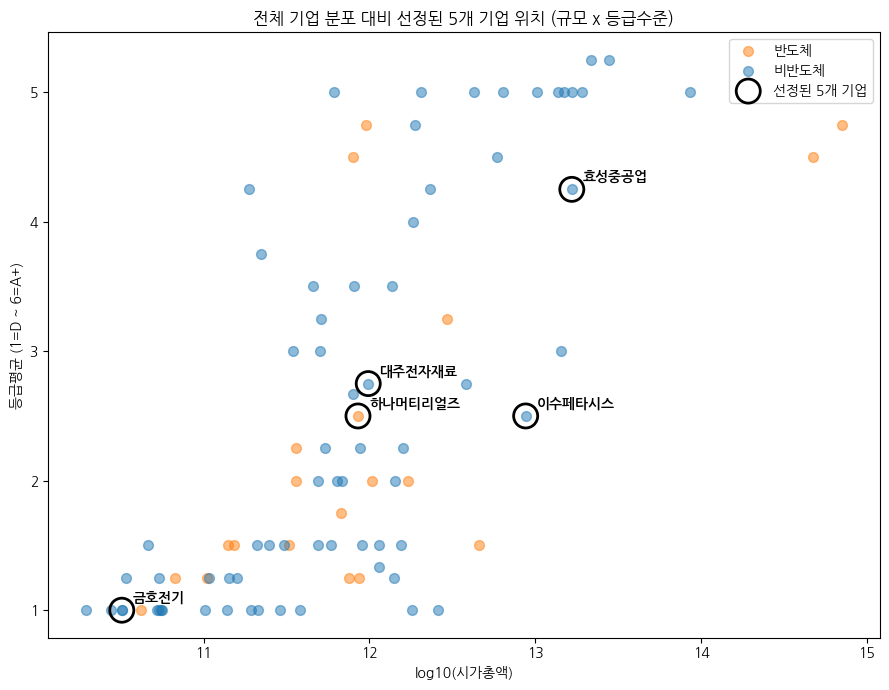

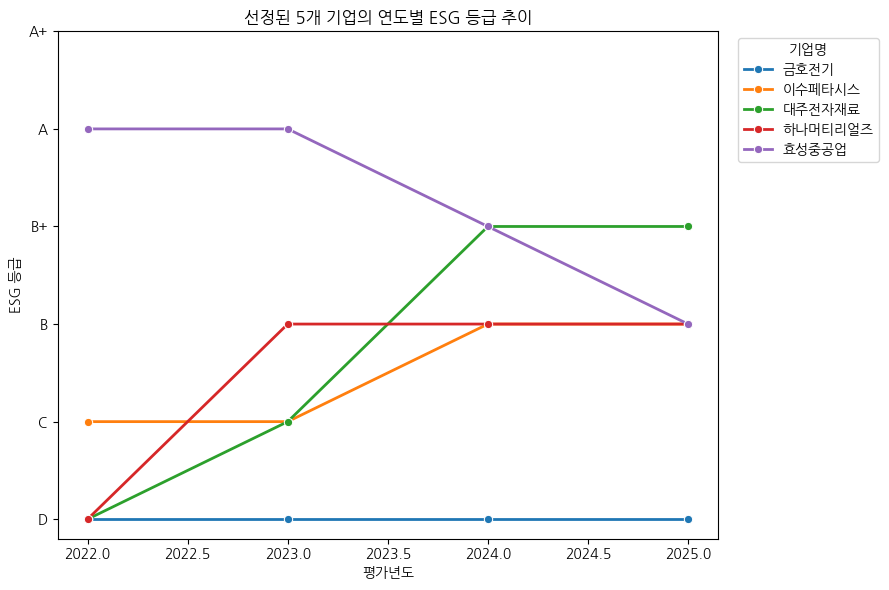


저장된 그래프: manual_matrix_table.png / manual_matrix_scatter.png / manual_matrix_trend.png


In [54]:


# ---------------------------------------------------------
# 1. 데이터 로드 & 전처리
# ---------------------------------------------------------
df = pd.read_excel(EDA_FILE_PATH)

grade_map = {'A+': 6, 'A': 5, 'B+': 4, 'B': 3, 'C': 2, 'D': 1}
df['ESG_num'] = df['ESG등급'].map(grade_map)
df['환경_num'] = df['환경'].map(grade_map)
df['사회_num'] = df['사회'].map(grade_map)
df['지배구조_num'] = df['지배구조'].map(grade_map)

semiconductor_codes = pd.read_excel(SEMICONDUCTOR_LIST_PATH)['기업코드'].unique()
# ※ 반도체_list.xlsx는 컬럼 밀림 이슈가 있으니 '기업코드' 외 컬럼은 사용하지 말 것

df_sorted = df.sort_values(['기업코드', '평가년도'])

# ---------------------------------------------------------
# 2. 기업 단위 피처 집계
# ---------------------------------------------------------
agg = df_sorted.groupby('기업코드').agg(
    기업명=('기업명', 'first'),
    산업코드=('산업코드', 'first'),
    시장구분=('시장구분', 'first'),
    연도수=('평가년도', 'nunique'),
    등급평균=('ESG_num', 'mean'),
    등급변동성=('ESG_num', 'std'),
    최신등급=('ESG_num', 'last'),
    최근시가총액=('시가총액', 'last'),
    보고서발행합=('지속가능경영보고서_발행', 'sum'),
    지배구조보고서발행합=('기업지배구조보고서_발행', 'sum'),
).reset_index()

first_grade = df_sorted.groupby('기업코드')['ESG_num'].first()
agg['등급추세'] = agg['최신등급'] - agg['기업코드'].map(first_grade)
agg['등급변동성'] = agg['등급변동성'].fillna(0)
agg['반도체여부'] = agg['기업코드'].isin(semiconductor_codes)

# 최근 연도 기준 E/S/G 서브점수 표준편차 (프로파일 불균형 정도)
latest_esg = df_sorted.groupby('기업코드')[['환경_num', '사회_num', '지배구조_num']].last()
latest_esg['ESG_편차'] = latest_esg[['환경_num', '사회_num', '지배구조_num']].std(axis=1)
agg = agg.merge(latest_esg[['ESG_편차']], on='기업코드')

# 규모 티어 (시가총액 3분위, 결측 제외 후 계산)
valid_cap = agg['최근시가총액'].dropna()
q1, q2 = valid_cap.quantile([1/3, 2/3])
def size_tier(x):
    if pd.isna(x):
        return '미상'
    return '소형' if x <= q1 else ('중형' if x <= q2 else '대형')
agg['규모티어'] = agg['최근시가총액'].apply(size_tier)

# 데이터 완전성 (4개년 모두 존재 + 보고서 발행 이력 있음 = 풍부)
agg['데이터완전성'] = np.where(
    (agg['연도수'] == 4) & (agg['보고서발행합'] > 0), '풍부',
    np.where(agg['보고서발행합'] == 0, '미발행', '보통')
)

print(f"규모티어 경계값: 소형 <= {q1:,.0f} < 중형 <= {q2:,.0f} < 대형")

# ---------------------------------------------------------
# 3. 매트릭스 기준으로 5개 기업 선정
# ---------------------------------------------------------
selected = {}

# ex1) 반도체 + 등급 개선 + KOSDAQ 소형주
cand = agg[(agg['반도체여부']) & (agg['등급추세'] > 0) &
           (agg['시장구분'] == 'KOSDAQ') & (agg['규모티어'] == '소형')]
if cand.empty:  # 조건 완화: 소형 제외
    cand = agg[(agg['반도체여부']) & (agg['등급추세'] > 0) & (agg['시장구분'] == 'KOSDAQ')]
selected['ex1_반도체·개선·KOSDAQ소형'] = cand.sort_values('등급추세', ascending=False).iloc[0]

# ex2) 비반도체 + 등급 하락 + KOSPI 대형주
cand = agg[(~agg['반도체여부']) & (agg['등급추세'] < 0) &
           (agg['시장구분'] == 'KOSPI') & (agg['규모티어'] == '대형')]
if cand.empty:
    cand = agg[(~agg['반도체여부']) & (agg['등급추세'] < 0) & (agg['시장구분'] == 'KOSPI')]
selected['ex2_비반도체·하락·KOSPI대형'] = cand.sort_values('등급추세').iloc[0]

# ex3) 등급 완전 안정(변동성 0) + 보고서 미발행 (데이터 부족 케이스)
cand = agg[(agg['등급변동성'] == 0) & (agg['데이터완전성'] == '미발행')]
if cand.empty:
    cand = agg[agg['데이터완전성'] == '미발행']
selected['ex3_안정·데이터부족'] = cand.sort_values('등급변동성').iloc[0]

# ex4) 등급 급변동(변동성 최상위) 기업 - 이미 선정된 기업 제외
excluded_codes = [v['기업코드'] for v in selected.values()]
cand = agg[(agg['연도수'] == 4) & (~agg['기업코드'].isin(excluded_codes))]
selected['ex4_등급급변동'] = cand.sort_values('등급변동성', ascending=False).iloc[0]

# ex5) E/S/G 서브점수 편차가 가장 큰 기업 - 이미 선정된 기업 제외
excluded_codes = [v['기업코드'] for v in selected.values()]
cand = agg[~agg['기업코드'].isin(excluded_codes)]
selected['ex5_ESG편차최대'] = cand.sort_values('ESG_편차', ascending=False).iloc[0]

selected_df = pd.DataFrame(selected).T.reset_index().rename(columns={'index': '선정기준'})

print("\n=== 수동 매트릭스 기준 5개 기업 선정 결과 ===")
print(selected_df[['선정기준', '기업명', '기업코드', '산업코드', '시장구분', '규모티어',
                    '등급평균', '등급추세', '등급변동성', 'ESG_편차', '반도체여부', '데이터완전성']].to_string(index=False))

# ---------------------------------------------------------
# 4. 시각화 (1) 선정 기준 매트릭스 히트맵 - 각 기업이 어떤 조건을 충족하는지 한눈에
# ---------------------------------------------------------
criteria_cols = ['반도체여부', '시장구분', '규모티어', '등급추세', '등급변동성', 'ESG_편차', '데이터완전성']
display_matrix = selected_df.set_index('기업명')[criteria_cols].copy()
display_matrix['반도체여부'] = display_matrix['반도체여부'].map({True: '반도체', False: '비반도체'})
display_matrix['등급추세'] = display_matrix['등급추세'].apply(lambda x: f'{x:+.1f}')
display_matrix['등급변동성'] = display_matrix['등급변동성'].round(2)
display_matrix['ESG_편차'] = display_matrix['ESG_편차'].round(2)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axis('off')
table = ax.table(cellText=display_matrix.values, rowLabels=display_matrix.index,
                  colLabels=display_matrix.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width(col=list(range(len(display_matrix.columns))))
table.scale(1, 2)
plt.title('선정된 5개 기업의 매트릭스 기준 충족 현황', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('manual_matrix_table.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 5. 시각화 (2) 전체 92개 기업 분포 위에 선정된 5개 강조 (규모 vs 등급평균, 반도체여부 색상)
# ---------------------------------------------------------
plt.figure(figsize=(9, 7))
plot_df = agg.dropna(subset=['최근시가총액']).copy()
plot_df['로그시가총액'] = np.log10(plot_df['최근시가총액'])

for is_semi, color, label in [(True, 'tab:orange', '반도체'), (False, 'tab:blue', '비반도체')]:
    subset = plot_df[plot_df['반도체여부'] == is_semi]
    plt.scatter(subset['로그시가총액'], subset['등급평균'], c=color, alpha=0.5, s=50, label=label)

sel_plot = selected_df.merge(plot_df[['기업코드', '로그시가총액']], on='기업코드', how='left')
plt.scatter(sel_plot['로그시가총액'], sel_plot['등급평균'],
            facecolors='none', edgecolors='black', s=300, linewidths=2, label='선정된 5개 기업')
for _, row in sel_plot.iterrows():
    plt.annotate(row['기업명'], (row['로그시가총액'], row['등급평균']),
                 textcoords="offset points", xytext=(8, 6), fontsize=10, fontweight='bold')

plt.xlabel('log10(시가총액)')
plt.ylabel('등급평균 (1=D ~ 6=A+)')
plt.title('전체 기업 분포 대비 선정된 5개 기업 위치 (규모 x 등급수준)')
plt.legend()
plt.tight_layout()
plt.savefig('manual_matrix_scatter.png', dpi=150)
plt.show()

# ---------------------------------------------------------
# 6. 시각화 (3) 선정 기업별 연도별 ESG 등급 추이 라인차트
# ---------------------------------------------------------
plt.figure(figsize=(9, 6))
sel_codes = selected_df['기업코드'].tolist()
trend_df = df[df['기업코드'].isin(sel_codes)].sort_values(['기업코드', '평가년도'])
sns.lineplot(data=trend_df, x='평가년도', y='ESG_num', hue='기업명', marker='o', linewidth=2)
plt.yticks(list(grade_map.values()), list(grade_map.keys()))
plt.xlabel('평가년도')
plt.ylabel('ESG 등급')
plt.title('선정된 5개 기업의 연도별 ESG 등급 추이')
plt.legend(title='기업명', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('manual_matrix_trend.png', dpi=150)
plt.show()

print("\n저장된 그래프: manual_matrix_table.png / manual_matrix_scatter.png / manual_matrix_trend.png")